<img src="https://www.unir.net/wp-content/uploads/2019/11/Unir_2021_logo.svg" width="240" height="240" align="center"/>

<center><h2>Análisis predictivo de riesgos de incendios forestales en Galicia con información satelital y meteorológica mediante técnicas de inteligencia artificial</h2></center>
<center><h3>Parte 2. Modelo predictivo</h3></center>

<center>Autora: Paula Nieto Zarza</center>

# 1. Importación de librerías

In [1]:
# Instalar librerías que no se encuentran en el primer notebook
# ----------------------------------------
!pip install seaborn
!pip install scikit-learn

In [2]:
# Librerías necesarias
# ----------------------------------------
# Librerías para manejar el dataset
import pandas as pd
import geopandas as gpd
import numpy as np

# Librerías para graficar
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para manejar la capa shp
import zipfile
import requests
import io

# Librerías para el preprocesamiento del dataset, entrenamiento del modelo, visualización del árbol y posterior predicción
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree

# Librerías para evaluar los modelos
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, 
                            f1_score, roc_curve, roc_auc_score, auc, average_precision_score, precision_recall_curve)

# Librerías para manejar la base de datos
from pymongo import MongoClient
from pathlib import Path
import os

In [3]:
# Visualizar las versiones de las librerías
# ----------------------------------------
!pip list

Package                   Version
------------------------- -----------
affine                    2.4.0
anyio                     4.12.1
anywidget                 0.11.0
argon2-cffi               25.1.0
argon2-cffi-bindings      25.1.0
arrow                     1.4.0
asttokens                 3.0.1
async-lru                 2.3.0
attrs                     26.1.0
babel                     2.18.0
backports.zstd            1.3.0
beautifulsoup4            4.14.3
bleach                    6.3.0
bqplot                    0.13.1
bqscales                  0.3.7
branca                    0.8.2
Brotli                    1.2.0
cached-property           1.5.2
certifi                   2026.2.25
cffi                      2.0.0
charset-normalizer        3.4.6
click                     8.4.0
click-plugins             1.1.1.2
cligj                     0.7.2
cloudpickle               3.1.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cryptography      

# 2. Conexión a MongoDB

In [4]:
# Realizar la conexión a MongoDB con el fin de importar y exportar las colecciones necesarias
# + Fuente: código obtenido del notebook "Uso de MongoDB desde Python.ipynb" de la asignatura bases de datos (curso 2025-2026) del Máster Universitario en Análisis y Visualización de Datos Masivos de la UNIR.
# + Autor original: Marlon Cardenas Bonett
# ----------------------------------------
BASE_DIR = Path().resolve()
DATA_DIR = BASE_DIR / "data"

def get_client(uri=None, **kwargs):
    uri = uri or os.getenv("MONGODB_URI", "mongodb://localhost:27017")
    params = {
        "maxPoolSize": 20,
        "minPoolSize": 2,
        "serverSelectionTimeoutMS": 5000,
        "socketTimeoutMS": 5000,
        "connectTimeoutMS": 5000,
    }
    params.update(kwargs)
    client = MongoClient(uri, **params)
    try:
        client.admin.command("ping")
    except ConnectionFailure as exc:
        raise RuntimeError(f"No se pudo conectar a MongoDB en {uri}") from exc
    return client

client = get_client()
print("Ping OK")
print("Bases disponibles:", client.list_database_names())

Ping OK
Bases disponibles: ['LabTestDB', 'Lab_BD', 'Proyecto', 'Proyecto2', 'Schools', 'TFM', 'admin', 'config', 'local', 'test']


In [5]:
# Conectar con la base de datos correspondiente
# ----------------------------------------
db = client["TFM"]

# 3. Dataset final para el modelo

In [6]:
# Obtener y mostrar la cabecera de la colección que contiene los partes de incendios, la información climática y de la cobertura del suelo de los municipios de Galicia desde 2010 a 2023
# ----------------------------------------
dataset = pd.DataFrame(list(db["Dataset final Galicia"].find()))
pd.set_option("display.max_columns", None)
dataset.head()

,_id,municipio,provincia,tmed,prec,tmin,tmax,hrMedia,hrMax,hrMin,lst,ndwi,estres,ndvi,evi,año,mes,dia,incendio
0,6a786085ebd4bec771f2f791,A Arnoia,Ourense,8.419713,2.077975,5.197557,11.392150,88.885853,100.311857,70.235253,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,1,No
1,6a786085ebd4bec771f2f792,A Arnoia,Ourense,8.288261,14.498429,5.075174,11.049092,92.802679,100.228883,87.641727,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,2,No
2,6a786085ebd4bec771f2f793,A Arnoia,Ourense,10.127730,0.663770,5.952886,14.262010,93.783095,100.235312,73.669642,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,3,No
3,6a786085ebd4bec771f2f794,A Arnoia,Ourense,7.427171,0.598191,4.597198,10.029002,89.512367,97.681098,83.750793,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,4,No
4,6a786085ebd4bec771f2f795,A Arnoia,Ourense,5.198957,-0.014362,1.798429,8.187671,83.996125,100.013595,68.841226,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,5,No


In [7]:
# Eliminar el campo de identificación que asigna MongoDB
# ----------------------------------------
dataset = dataset.drop(columns= ["_id"])

In [8]:
# Explorar la estructura del dataset (dimensiones, nombre de los campos, tipos de datos y valores no nulos)
# ----------------------------------------
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 1604532 entries, 0 to 1604531
Data columns (total 18 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   municipio  1604532 non-null  str    
 1   provincia  1604532 non-null  str    
 2   tmed       1604532 non-null  float64
 3   prec       1604532 non-null  float64
 4   tmin       1604532 non-null  float64
 5   tmax       1604532 non-null  float64
 6   hrMedia    1604532 non-null  float64
 7   hrMax      1604532 non-null  float64
 8   hrMin      1604532 non-null  float64
 9   lst        1604532 non-null  float64
 10  ndwi       1604532 non-null  float64
 11  estres     1604532 non-null  float64
 12  ndvi       1604532 non-null  float64
 13  evi        1604532 non-null  float64
 14  año        1604532 non-null  int64  
 15  mes        1604532 non-null  int64  
 16  dia        1604532 non-null  int64  
 17  incendio   1604532 non-null  str    
dtypes: float64(12), int64(3), str(3)
memory usage: 220.3 

# 4. Preprocesamiento del dataset

### 4.1. Label Encoding

In [9]:
# Obtener el número y nombre de aquellas columnas de tipo texto
# ----------------------------------------
str_cols = dataset.select_dtypes(include= ["str"]).columns
print(f"--- Hay {len(str_cols)} columnas de tipo texto ---")

for col in str_cols:
    print(f"+ {dataset[col].name}")

--- Hay 3 columnas de tipo texto ---
+ municipio
+ provincia
+ incendio


In [10]:
# Codificar los valores únicos cualitativos con la técnica de codificación Label Encoding, y mostrar la cabecera para observar los nuevos valores de dichos valores
# + Fuente: https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/
# ----------------------------------------
# Diccionario para guardar un encoder por columna
encoders = {}
for col in str_cols:
    label_encoder = LabelEncoder()
    dataset[col] = label_encoder.fit_transform(dataset[col])
    encoders[col] = label_encoder

dataset.head()

,municipio,provincia,tmed,prec,tmin,tmax,hrMedia,hrMax,hrMin,lst,ndwi,estres,ndvi,evi,año,mes,dia,incendio
0,0,2,8.419713,2.077975,5.197557,11.392150,88.885853,100.311857,70.235253,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,1,0
1,0,2,8.288261,14.498429,5.075174,11.049092,92.802679,100.228883,87.641727,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,2,0
2,0,2,10.127730,0.663770,5.952886,14.262010,93.783095,100.235312,73.669642,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,3,0
3,0,2,7.427171,0.598191,4.597198,10.029002,89.512367,97.681098,83.750793,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,4,0
4,0,2,5.198957,-0.014362,1.798429,8.187671,83.996125,100.013595,68.841226,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,5,0


### 4.2. División del dataset 

In [11]:
# Inicializar en la variable X todas las columnas independientes y en la variable Y la variable dependiente.
# Después, separar el conjunto en datos de entrenamiento y test controlando la mezcla aleatoria
# + Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# ----------------------------------------
X = dataset.drop("incendio", axis=1)
y = dataset["incendio"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, stratify= y, random_state= 42)

In [12]:
# Submuestrear el conjunto de datos para que de 1 muestra de la clase minoritaria (incendio), haya 5 de la mayoritaria (no incendio).
# A continuación, reconstruir el dataframe con los nombres originales
# + Fuente: https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html
# ----------------------------------------
submuestreo = RandomUnderSampler(sampling_strategy= 0.2, random_state= 16) 
X_train_sub, y_train_sub = submuestreo.fit_resample(X_train, y_train)

X_train_sub = pd.DataFrame(X_train_sub, columns= X.columns)

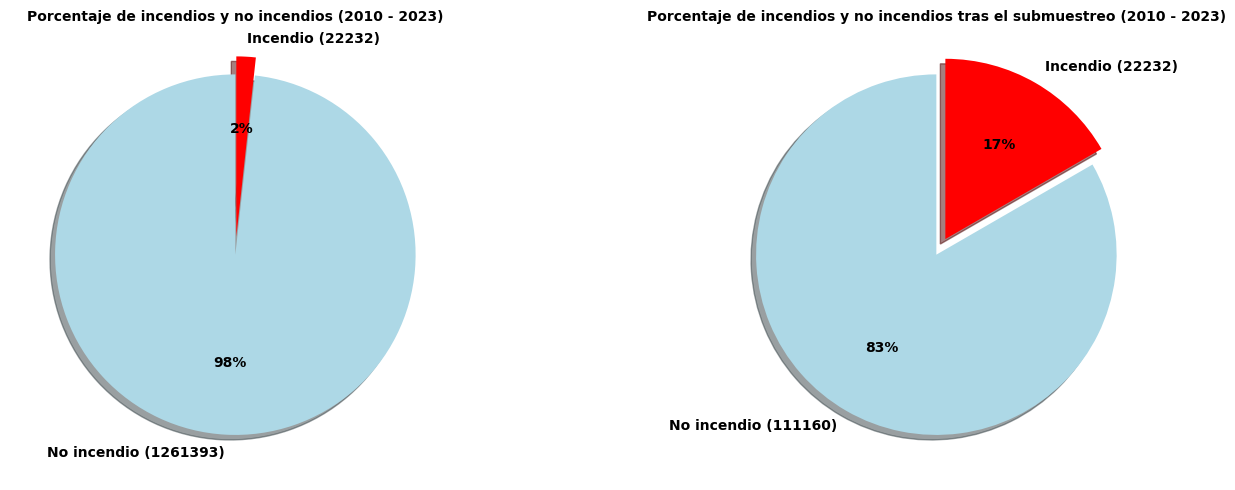

In [13]:
# Graficar el porcentaje de registros que indican si ha ocurrido un incendio o no del conjunto de origen y tras aplicar el submuestreo
# + Fuente: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html#sphx-glr-gallery-pie-and-polar-charts-pie-features-py
# ----------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Pporcentaje de incendios y no incendios 
num_no_incendio = y_train[y_train== 0].size
num_incendio = y_train[y_train== 1].size
data = [num_no_incendio, num_incendio]

ax[0].pie(data, labels= ["No incendio (%d)" % num_no_incendio, "Incendio (%d)" % num_incendio], textprops= {"fontweight": "bold"}, autopct= "%1.0f%%", 
          colors= ["lightblue","red"], shadow= True, startangle= 90, explode= (0.0, 0.1))
ax[0].set_title("Porcentaje de incendios y no incendios (2010 - 2023)", fontdict= {"fontsize": 10, "fontweight": "bold"})

# Porcentaje de incendios y no incendios tras el submuestreo
num_no_incendio_sub = y_train_sub[y_train_sub== 0].size
num_incendio_sub = y_train_sub[y_train_sub== 1].size
data_sub = [num_no_incendio_sub, num_incendio_sub]

ax[1].pie(data_sub, labels= ["No incendio (%d)" % num_no_incendio_sub, "Incendio (%d)" % num_incendio_sub], textprops= {"fontweight": "bold"}, autopct= "%1.0f%%", 
          colors= ["lightblue","red"], shadow= True, startangle= 90, explode= (0.0, 0.1))
ax[1].set_title("Porcentaje de incendios y no incendios tras el submuestreo (2010 - 2023)", fontdict= {"fontsize": 10, "fontweight": "bold"})

plt.tight_layout()
plt.show()

# 5. Entremamiento del modelo

In [14]:
# Preparar el modelo de clasificación Random Forest y entrenarlo con el conjunto de datos con submuestreo
# + Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# ----------------------------------------
rf = RandomForestClassifier(n_estimators= 600, class_weight= "balanced", random_state= 42, n_jobs= -1)

rf.fit(X_train_sub, y_train_sub)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

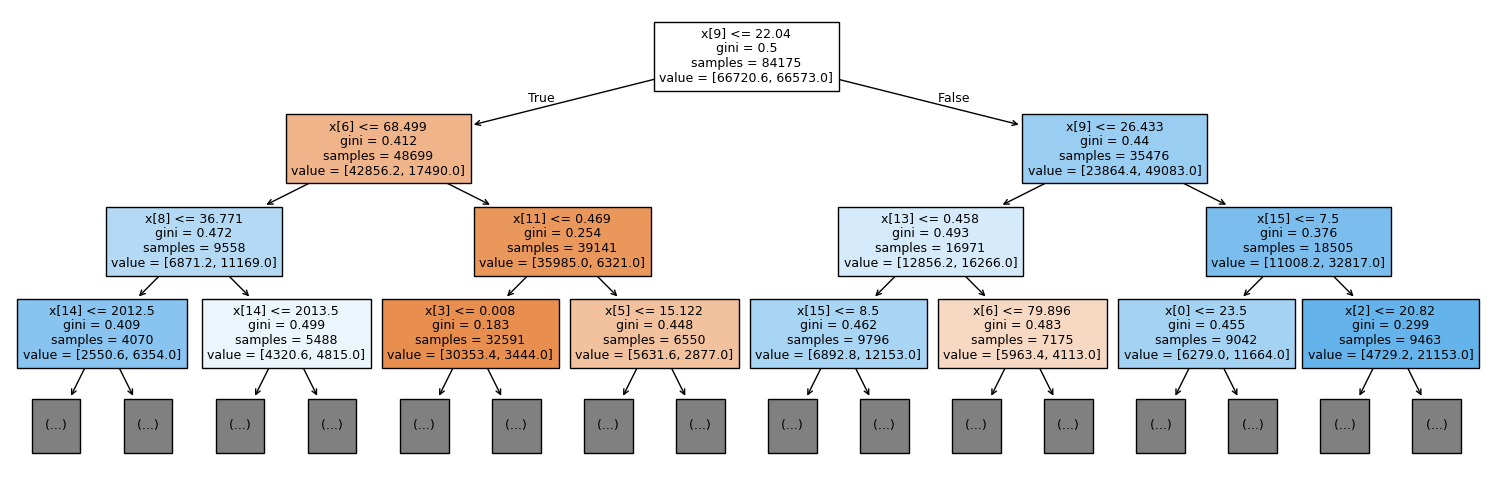

In [15]:
# Graficar el algoritmo Random Forest creado hasta el nivel 3
# + Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html
# ----------------------------------------
plt.figure(figsize= (19, 6))
tree.plot_tree(rf.estimators_[0], filled= True, max_depth= 3, fontsize= 9)
plt.show()

### 5.1. Predicción y probabilidad

In [16]:
# Predecir para cada registro a que clase pertenece y la probabilidad que hay detrás de esta predicción, con ayuda del modelo y los datos de test
# + Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# ----------------------------------------
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)

In [17]:
# Mostrar el resumen estadístico de la probabilidad de la clase 1 (ha habido incendio) según las clases para determinar el umbral
# ----------------------------------------
probabilidad = pd.DataFrame({"y_test": y_test, "y_proba": y_proba[:, 1]})
probabilidad.groupby("y_test")["y_proba"].describe()

,count,mean,std,min,25%,50%,75%,max
y_test,,,,,,,,
0,315349.0,0.103362,0.141271,0.0,0.006667,0.036667,0.150,0.988333
1,5558.0,0.495906,0.276383,0.0,0.265000,0.465000,0.735,1.000000


<Figure size 600x500 with 0 Axes>

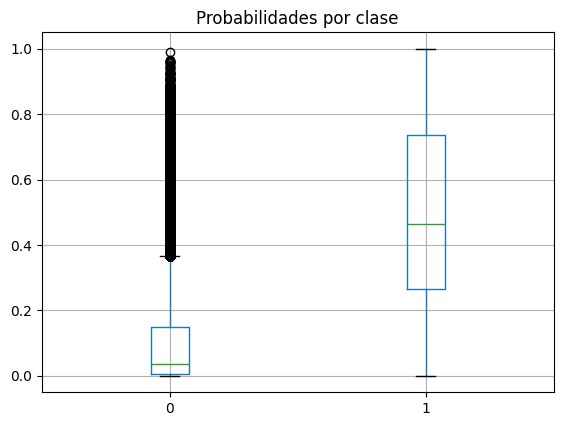

In [18]:
# Graficar los valores posibles de la probabilidad de cada clase (0 -> no ha habido incendio; 1 -> si ha habido incendio)
# + Fuente: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.boxplot.html
# ----------------------------------------
plt.figure(figsize=(6,5))

probabilidad.boxplot(column= "y_proba", by= "y_test")
plt.title("Probabilidades por clase")
plt.suptitle("")
plt.ylabel("")
plt.xlabel("")
plt.show()

# 6. Evaluación del modelo

In [19]:
# Asignar el nuevo umbral (promedio de los valores medios de la probabilidad en los registros correspondientes a 0 y 1)
# ----------------------------------------
umbral = 0.3
y_pred_03 = (y_proba[:, 1] >= umbral).astype(int)

In [20]:
# Calcular la matríz de confusión
# + Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
# ----------------------------------------
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_03).ravel()

print(f"+ Verdaderos positivos (TP) -> {tp}")
print(f"+ Falsos negativos (FN) -> {fn}")
print(f"+ Falsos positivos (FP) -> {fp}")
print(f"+ Verdaderos negativos (TN) -> {tn}")

+ Verdaderos positivos (TP) -> 3908
+ Falsos negativos (FN) -> 1650
+ Falsos positivos (FP) -> 32969
+ Verdaderos negativos (TN) -> 282380


In [21]:
# Obtener el número de instancias clasificadas correcta e incorrectamente
# ----------------------------------------
ins_correctas = tp + tn
print(f"+ Instancias clasificadas correctamente -> {ins_correctas:.0f}")
ins_incorrectas = fp + fn
print(f"+ Instancias clasificadas incorrectamente -> {ins_incorrectas:.0f}")

+ Instancias clasificadas correctamente -> 286288
+ Instancias clasificadas incorrectamente -> 34619


In [22]:
# Visualizar los resultados de diferentes métricas
# + Fuente "accuracy_score": https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html#sklearn.metrics.accuracy_score
# + Fuente "precision_score": https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html#sklearn.metrics.precision_score
# + Fuente "recall_score": https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html#sklearn.metrics.recall_score
# + Fuente "f1_score": https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score
# ----------------------------------------
acc = accuracy_score(y_test, y_pred_03)
print(f"+ Accuracy -> {acc:.3f}")

precision = precision_score(y_test, y_pred_03, average= "weighted")
print(f"+ Precision del modelo -> {precision:.3f}")

recall = recall_score(y_test, y_pred_03, average= "weighted")
print(f"+ Recall del modelo -> {recall:.3f}")

f1 = f1_score(y_test, y_pred_03, average= "weighted")
print(f"+ F1-score del modelo -> {f1:.3f}")

fp_rate = fp / (fp + tn)
print(f"+ FP rate del modelo -> {fp_rate:.4f}")

+ Accuracy -> 0.892
+ Precision del modelo -> 0.979
+ Recall del modelo -> 0.892
+ F1-score del modelo -> 0.929
+ FP rate del modelo -> 0.1045


In [23]:
# Visualizar algunas de las métricas anteriores para cada clase
# + Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
# ----------------------------------------
print(f"{classification_report(y_test, y_pred_03, target_names= ["No incendio", "Incendio"])}")

              precision    recall  f1-score   support

 No incendio       0.99      0.90      0.94    315349
    Incendio       0.11      0.70      0.18      5558

    accuracy                           0.89    320907
   macro avg       0.55      0.80      0.56    320907
weighted avg       0.98      0.89      0.93    320907



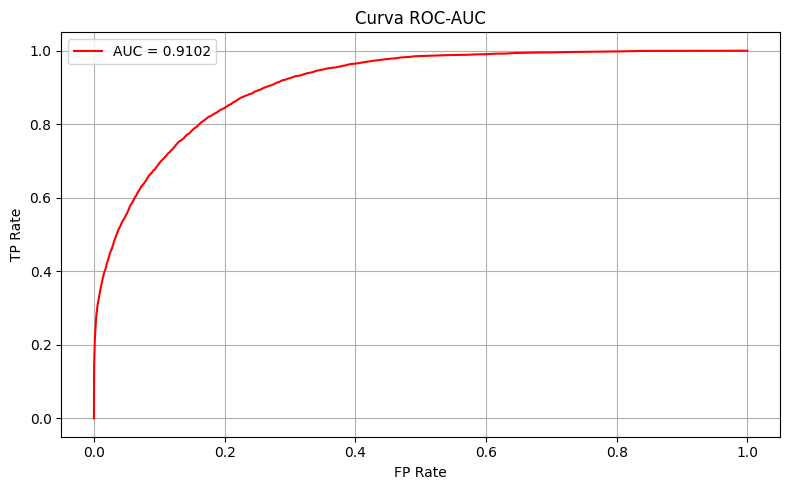

In [24]:
# Graficar la curva ROC-AUC, la cual no cambia por el umbral
# + Fuente: https://statologos.com/plot-roc-curve-python/
# ----------------------------------------
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])
auc = roc_auc_score(y_test, y_proba[:, 1])

plt.figure(figsize= (8, 5))
plt.plot(fpr, tpr, color= "red", label= f"AUC = {auc:.4f}")
plt.xlabel("FP Rate")
plt.ylabel("TP Rate")
plt.title("Curva ROC-AUC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

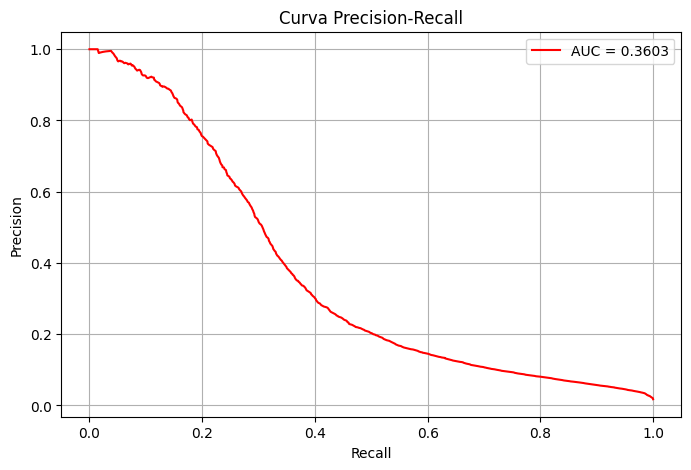

In [25]:
# Graficar la curva PR, la cual no cambia por el umbral
# + Fuente: https://www.datacamp.com/es/tutorial/precision-recall-curve-tutorial
# + Fuente "average_precision_score": https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.htmlc
# ----------------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_proba[:, 1])
auc_pr = average_precision_score(y_test, y_proba[:, 1])

plt.figure(figsize= (8, 5))
plt.plot(recall, precision, color= "red", label= f"AUC = {auc_pr:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.legend()
plt.grid(True)
plt.show()

# 7. Analizar los resultados

### 7.1. Dataset final

In [26]:
# Crear el dataset final con la probabilidad y predicción de todos los registros. 
# Después, convertir los valores codificados de nuevo en las etiquetas originales
# + Fuente "inverse_transform": https://www.geeksforgeeks.org/machine-learning/ml-label-encoding-of-datasets-in-python/
# ----------------------------------------
probabilidad = rf.predict_proba(X)[:, 1]
prediccion = (probabilidad >= umbral).astype(int)

dataset_final = X.copy()
dataset_final["probabilidad"] = probabilidad
dataset_final["prediccion"] = prediccion

dataset_final["municipio"] = encoders["municipio"].inverse_transform(dataset_final["municipio"])
dataset_final["provincia"] = encoders["provincia"].inverse_transform(dataset_final["provincia"])

dataset_final.head()

,municipio,provincia,tmed,prec,tmin,tmax,hrMedia,hrMax,hrMin,lst,ndwi,estres,ndvi,evi,año,mes,dia,probabilidad,prediccion
0,A Arnoia,Ourense,8.419713,2.077975,5.197557,11.392150,88.885853,100.311857,70.235253,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,1,0.005000,0
1,A Arnoia,Ourense,8.288261,14.498429,5.075174,11.049092,92.802679,100.228883,87.641727,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,2,0.001667,0
2,A Arnoia,Ourense,10.127730,0.663770,5.952886,14.262010,93.783095,100.235312,73.669642,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,3,0.005000,0
3,A Arnoia,Ourense,7.427171,0.598191,4.597198,10.029002,89.512367,97.681098,83.750793,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,4,0.001667,0
4,A Arnoia,Ourense,5.198957,-0.014362,1.798429,8.187671,83.996125,100.013595,68.841226,4.444382,-0.593221,0.220123,0.665976,0.293764,2010,1,5,0.010000,0


### 7.2. Capa shapefile de Galicia

In [27]:
# Llamar y mostrar la cabecera del archivo de los municipios de Galicia guardado en el repositorio "TFM_codigo_datos" del GitHub
# ----------------------------------------
url = "https://github.com/Paulaa257/TFM_codigo_datos/raw/refs/heads/main/Concellos_IGN.zip"

request_url = requests.get(url)
municipios_zip = zipfile.ZipFile(io.BytesIO(request_url.content))
municipios_zip.extractall("datos")

municipios_galicia = gpd.read_file("datos/Concellos_IGN/Concellos_IGN.shp")
municipios_galicia.head()

,INSPIREID,COUNTRY,NATLEV,NATLEVNAME,NATCODE,NAMEUNIT,CODNUT1,CODNUT2,CODNUT3,CODPROV,CODCONC,PROVINCIA,CONCELLO,NOMECAPITA,Shape_Leng,Shape_Area,geometry
0,ES.IGN.BDDAE.34123232078,ES,https://inspire.ec.europa.eu/codelist/Administ...,Municipio,34123232078,Sarreaus,ES1,ES11,ES113,32,32078,Ourense,Sarreaus,Sarreaus,40754.204239,7.725592e+07,"POLYGON ((608813.196 4664453.146, 608701.934 4..."
1,ES.IGN.BDDAE.34123232079,ES,https://inspire.ec.europa.eu/codelist/Administ...,Municipio,34123232079,Taboadela,ES1,ES11,ES113,32,32079,Ourense,Taboadela,Taboadela,23378.042655,2.517205e+07,"POLYGON ((593815.346 4676211.812, 593751.767 4..."
2,ES.IGN.BDDAE.34123232036,ES,https://inspire.ec.europa.eu/codelist/Administ...,Municipio,34123232036,Xunqueira de Ambía,ES1,ES11,ES113,32,32036,Ourense,Xunqueira de Ambía,Xunqueira de Ambía,44065.819696,6.017702e+07,"POLYGON ((601412.121 4677008.137, 601727.493 4..."
3,ES.IGN.BDDAE.34123232037,ES,https://inspire.ec.europa.eu/codelist/Administ...,Municipio,34123232037,Xunqueira de Espadanedo,ES1,ES11,ES113,32,32037,Ourense,Xunqueira de Espadanedo,Xunqueira de Espadanedo,22369.750668,2.763993e+07,"POLYGON ((609578.338 4685452.972, 609665.855 4..."
4,ES.IGN.BDDAE.34123232038,ES,https://inspire.ec.europa.eu/codelist/Administ...,Municipio,34123232038,Larouco,ES1,ES11,ES113,32,32038,Ourense,Larouco,Larouco,22564.684745,2.368581e+07,"POLYGON ((648454.241 4688318.351, 648458.62 46..."


### 7.3. Análisis de variables

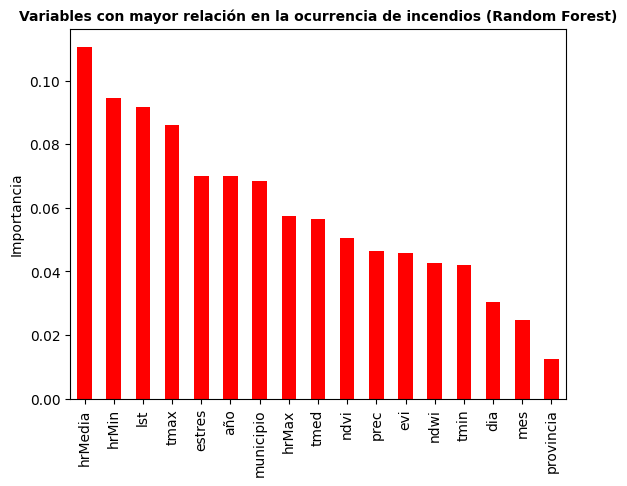

In [28]:
# Graficar la importancia de cada atributo de entrada según el modelo entrenado Random Forest
# + Fuente: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html
# ----------------------------------------
importances = pd.Series(rf.feature_importances_, index= X.columns)
importances.sort_values(ascending= False).plot(kind= "bar", color= "red")
plt.title("Variables con mayor relación en la ocurrencia de incendios (Random Forest)", fontweight= "bold", fontsize= 10)
plt.ylabel("Importancia")
plt.show()

### 7.4. Análisis temporal

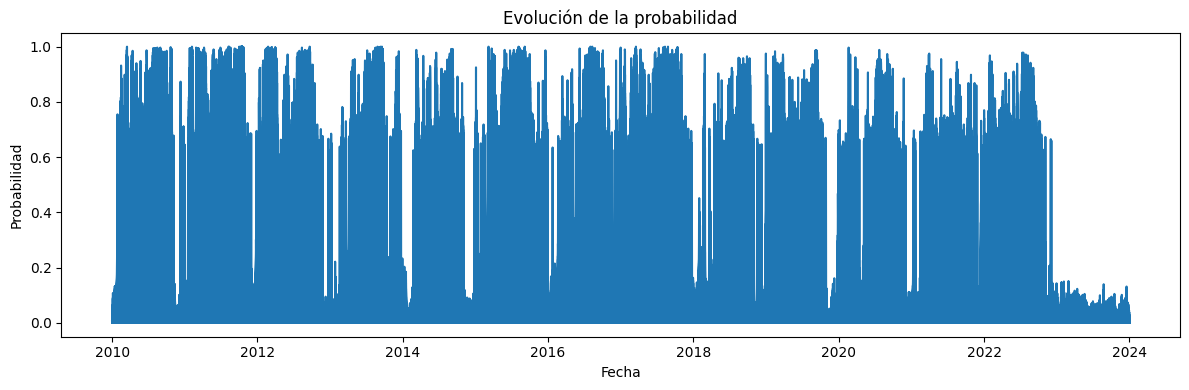

In [29]:
# Visualizar en una serie temporal la evolución de la probabilidad en los años de estudio 
# ----------------------------------------
dataset_final["fecha"] = pd.to_datetime(dataset_final[["año", "mes", "dia"]].rename(columns={"año": "year", "mes": "month", "dia": "day"}))

plt.figure(figsize= (12, 4))
plt.plot(dataset_final["fecha"], dataset_final["probabilidad"])
plt.xlabel("Fecha")
plt.ylabel("Probabilidad")
plt.title("Evolución de la probabilidad")
plt.tight_layout()
plt.show()

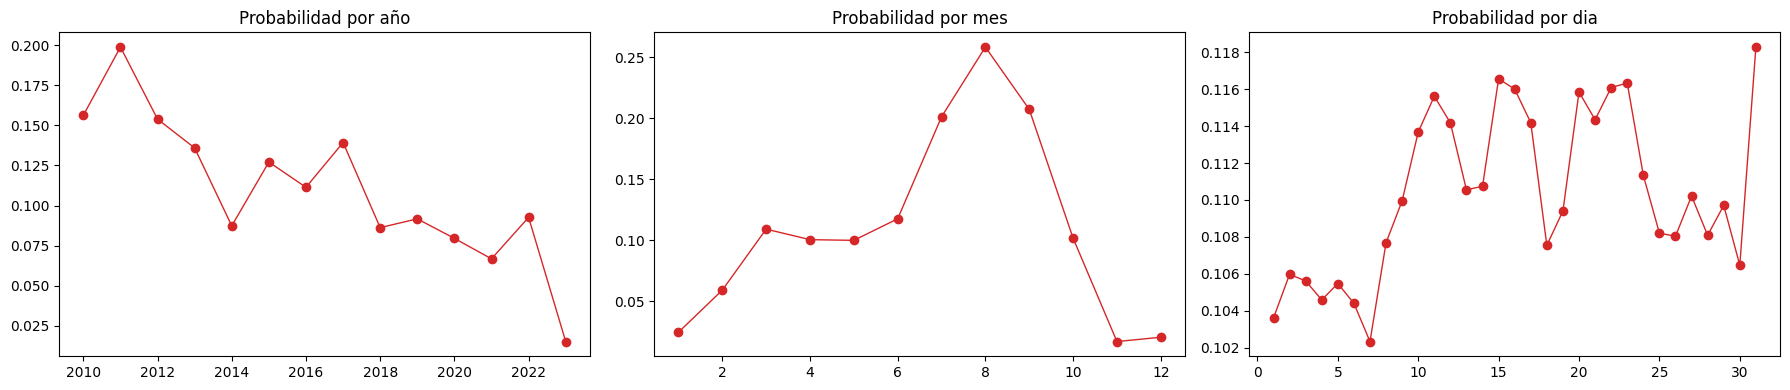

In [30]:
# Graficar la media de probabilidad por año, mes y día
# ----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, col in zip(axes, ["año", "mes", "dia"]):
    media = dataset_final.groupby(col)["probabilidad"].mean()
    ax.plot(media.index, media.values, color="tab:red", marker='o', linewidth=1)
    ax.set_title(f"Probabilidad por {col}")

plt.tight_layout()
plt.show()

### 7.5. Análisis espacial

In [31]:
# Calcular la probabilidad media por municipio y seleccionar los 100 con mayor probabilidad de incendio
# ----------------------------------------
promedio_municipio = dataset_final.groupby("municipio")["probabilidad"].mean().sort_values(ascending= False)

muni_mayor_prob = promedio_municipio.head(100)
muni_mayor_prob

municipio
Vilariño de Conso    0.237600
Viana do Bolo        0.234459
Verín                0.230062
Oímbra               0.223104
Cualedro             0.220879
                       ...   
Pazos de Borbén      0.131168
San Xoán de Río      0.131134
Rairiz de Veiga      0.131048
Celanova             0.130922
Folgoso do Courel    0.130638
Name: probabilidad, Length: 100, dtype: float64

In [32]:
# Unir la capa de municipios de Galicia con la variable creada anteriormente
# ----------------------------------------
muni_mayor_prob.columns = ["municipio", "probabilidad"]
muni_100 = municipios_galicia.merge(muni_mayor_prob, left_on= "NAMEUNIT", right_on= "municipio", how= "left")

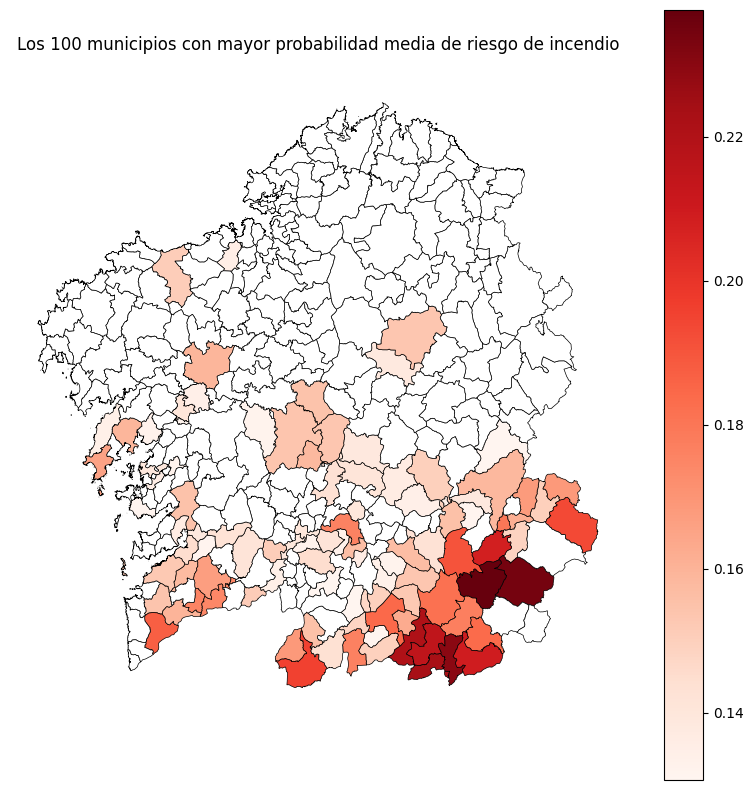

In [33]:
# Representar la capa de municipios de Galicia como base, y 100 municipios coloreados con una escala rojiza que presentan mayor probabilidad predicha de incendio 
# ----------------------------------------
fig, ax = plt.subplots(figsize= (8, 8))

muni_100.plot(column= "probabilidad", ax= ax, cmap= "Reds", edgecolor= "black", linewidth= 0.5, legend= True, missing_kwds= {"color": "white"})

ax.set_title("Los 100 municipios con mayor probabilidad media de riesgo de incendio")
ax.axis("off")
plt.tight_layout()
plt.show()

# 8. Subir a MongoDB

In [35]:
# Crear la colección e insertar los datos que previamente se han convertido de dataframe a lista de diccionarios (JSON)
# ----------------------------------------
coleccion_resultado_modelo_predictivo = db["Probabilidad riesgo de incendios Galicia"]
datos_resultado_modelo_predictivo_json = dataset_final.to_dict(orient= "records")

if len(datos_resultado_modelo_predictivo_json) > 0:
    coleccion_resultado_modelo_predictivo.insert_many(datos_resultado_modelo_predictivo_json)
    print(f"Se insertaron {len(datos_resultado_modelo_predictivo_json)} documentos correctamente")
else:
    print("No hay documento que insertar")

Se insertaron 1604532 documentos correctamente
